# 15. Atmosferik CO₂ Zaman Serisi Tahmini

**Kategori:** Zaman Serisi  
**Gerçek veri seti:** Mauna Loa Weekly Atmospheric CO₂ (statsmodels)  
**Veri kaynağı:** [https://www.statsmodels.org/stable/datasets/generated/co2.html](https://www.statsmodels.org/stable/datasets/generated/co2.html)  
**Amaç:** Aylık CO₂ ortalamasını gecikmeli ve mevsimsel özelliklerle tahmin etmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Zaman serisini hazırlama ve EDA

In [2]:
df = pd.read_csv(DATA_DIR / "co2_weekly.csv", parse_dates=["date"]).set_index("date")
print("Tarih aralığı:", df.index.min().date(), "-", df.index.max().date())
print("Haftalık gözlem:", len(df), "| Eksik:", int(df.co2.isna().sum()))
monthly = df.co2.resample("MS").mean().interpolate()
display(monthly.describe().to_frame().T)

Tarih aralığı: 1958-03-29 - 2001-12-29
Haftalık gözlem: 2284 | Eksik: 59


,count,mean,std,min,25%,50%,75%,max
co2,526.0,339.619202,17.116453,313.4,324.025,337.9125,354.5375,373.8


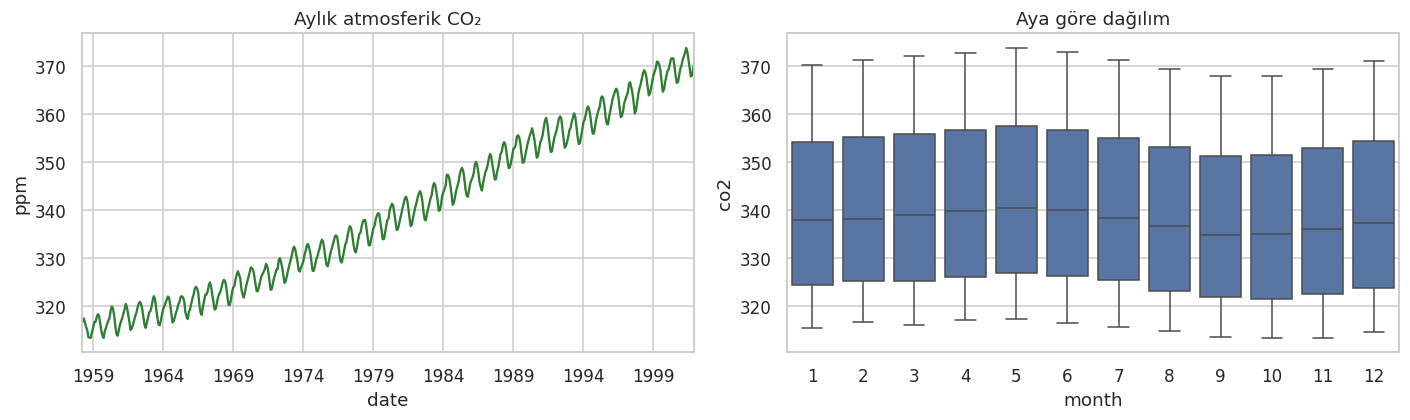

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
monthly.plot(ax=axes[0], color="#2E7D32"); axes[0].set(title="Aylık atmosferik CO₂", ylabel="ppm")
seasonal = pd.DataFrame({"co2": monthly.values, "month": monthly.index.month})
sns.boxplot(data=seasonal, x="month", y="co2", ax=axes[1])
axes[1].set(title="Aya göre dağılım")
plt.tight_layout(); plt.show()

## 2. Zaman sırasını koruyan tahmin

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

features = pd.DataFrame({
    "lag_1": monthly.shift(1), "lag_12": monthly.shift(12),
    "rolling_12": monthly.shift(1).rolling(12).mean(),
    "trend": np.arange(len(monthly)),
    "sin12": np.sin(2 * np.pi * monthly.index.month / 12),
    "cos12": np.cos(2 * np.pi * monthly.index.month / 12),
}, index=monthly.index).dropna()
target = monthly.loc[features.index]
split = -36
X_train, X_test = features.iloc[:split], features.iloc[split:]
y_train, y_test = target.iloc[:split], target.iloc[split:]
candidates = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                            random_state=RANDOM_STATE, n_jobs=-1),
}
fitted = {name: model.fit(X_train, y_train) for name, model in candidates.items()}
preds = {name: model.predict(X_test) for name, model in fitted.items()}
scores = pd.DataFrame({name: {"MAE": mean_absolute_error(y_test, pred),
                              "RMSE": root_mean_squared_error(y_test, pred)}
                       for name, pred in preds.items()}).T.sort_values("MAE")
display(scores.round(3))

,MAE,RMSE
Ridge,0.373,0.463
Random Forest,1.774,2.218


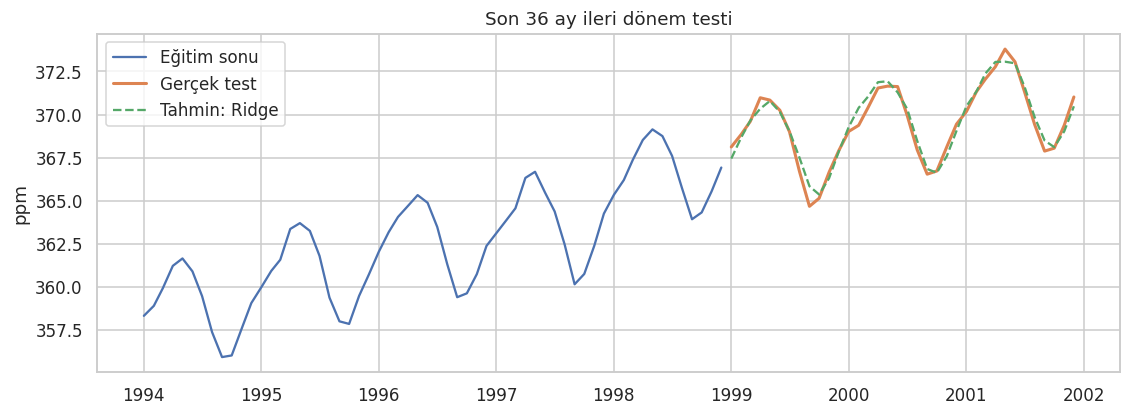

In [5]:
best_name = scores.index[0]; best_model = fitted[best_name]; best_pred = preds[best_name]
plt.figure(figsize=(12, 4))
plt.plot(y_train.index[-60:], y_train.iloc[-60:], label="Eğitim sonu")
plt.plot(y_test.index, y_test, label="Gerçek test", linewidth=2)
plt.plot(y_test.index, best_pred, "--", label=f"Tahmin: {best_name}")
plt.title("Son 36 ay ileri dönem testi"); plt.ylabel("ppm"); plt.legend(); plt.show()
joblib.dump({"best_name": best_name, "best_model": best_model,
             "all_models": fitted, "features": features.columns.tolist(),
             "metrics": scores.to_dict()}, MODEL_DIR / "15_co2_zaman_serisi.joblib")
json.dump({"best_model": best_name, **scores.loc[best_name].to_dict()},
          open(RESULT_DIR / "15_co2.json", "w"), indent=2)

## Sonuç

Rastgele train/test ayrımı yapılmadı; son 36 ay ileri dönem testidir. Tüm gecikmeli ve hareketli
ortalama özellikleri yalnızca geçmiş gözlemlerden üretildi. Bu, zaman serilerinde gelecek bilgisinin
eğitime sızmasını engeller.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **gecikmeli özelliklerle zaman serisi tahmini** biçimindedir.
Bu notebookta **gerçek 1958–2001 CO₂ serisi, eksik haftalar, mevsimsellik EDA'sı ve ileri dönem testi** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).